In [1]:
import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt

from utilities import *

%matplotlib widget

In [2]:
new = '/store/carroll/col/2018/raw/rmbl/'
old = '/store/brodrick/col/raw_data/'
flight = 'NIS01_20180619_153052'

In [3]:
# confirmed phil has 7 days, so far Tristan has only uploaded reprocessed data for first 4 days
dates = set([x.split('_')[1] for x in os.listdir(os.path.join(old, 'all_radiance'))])
dates

{'20180612',
 '20180613',
 '20180619',
 '20180620',
 '20180621',
 '20180625',
 '20180626'}

In [28]:
# # add byte order to all new data associated w this flightling
# fps = glob(new + f'*/*{flight}*.hdr')
# for fp in fps:
#     add_byte_order(fp)

In [ ]:
# check rdn, loc, obs data

In [4]:
# rdn
fp_new = glob(os.path.join(new, '*', f'{flight}_rdn.hdr'))[0]
fp_old = glob(os.path.join(old, '*', f'{flight}_rdn.hdr'))[0]

rdn_new = envi.open(fp_new).open_memmap(interleave='bip')
rdn_old = envi.open(fp_old).open_memmap(interleave='bip')

print(rdn_new.shape, rdn_old.shape)

# np.array_equal(rdn_new, rdn_old)

(47530, 598, 426) (47530, 598, 426)


/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/spectral/io/envi.py:175: UserWarning: Parameters with non-lowercase names encountered and converted to lowercase. To retain source file parameter name capitalization, set spectral.settings.envi_support_nonlowercase_params to True.
  warnings.warn(msg)


In [6]:
dif = np.where(rdn_new[0:500, 0:500, :] != rdn_old[0:500, 0:500, :])

135


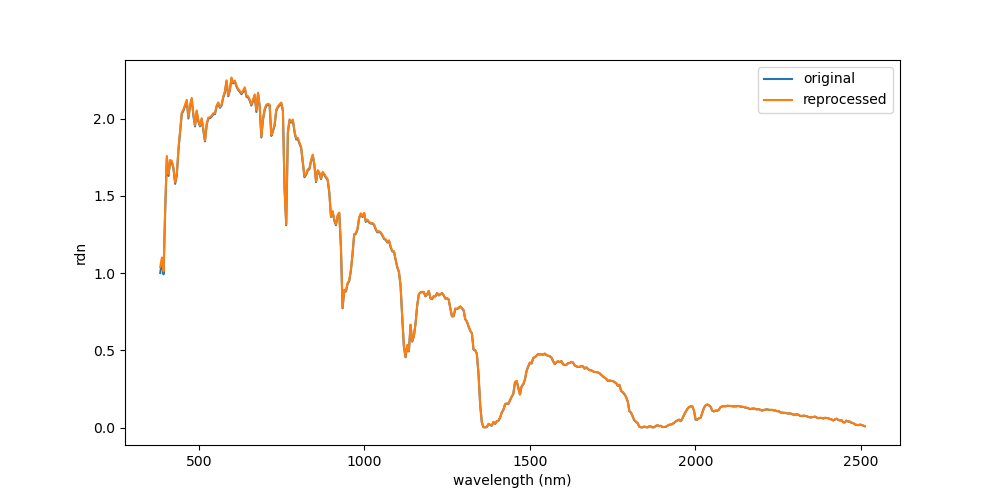

456


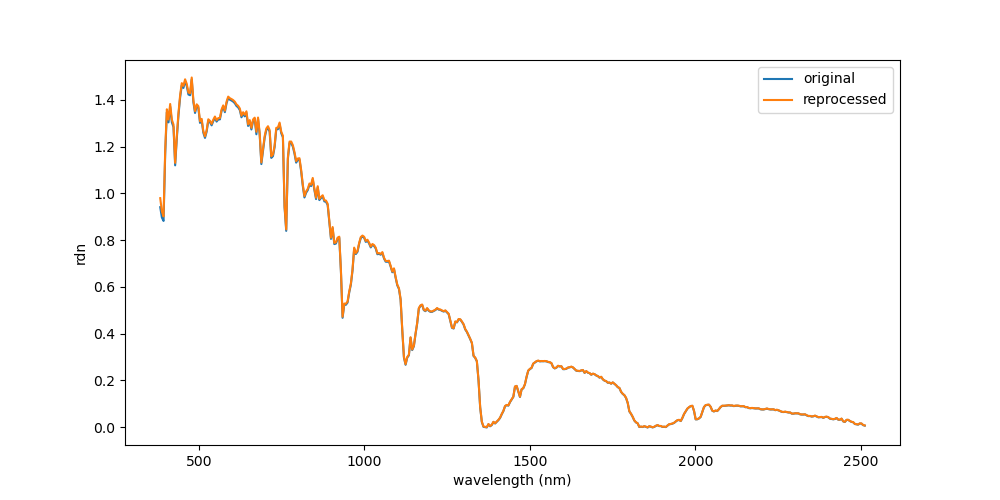

408


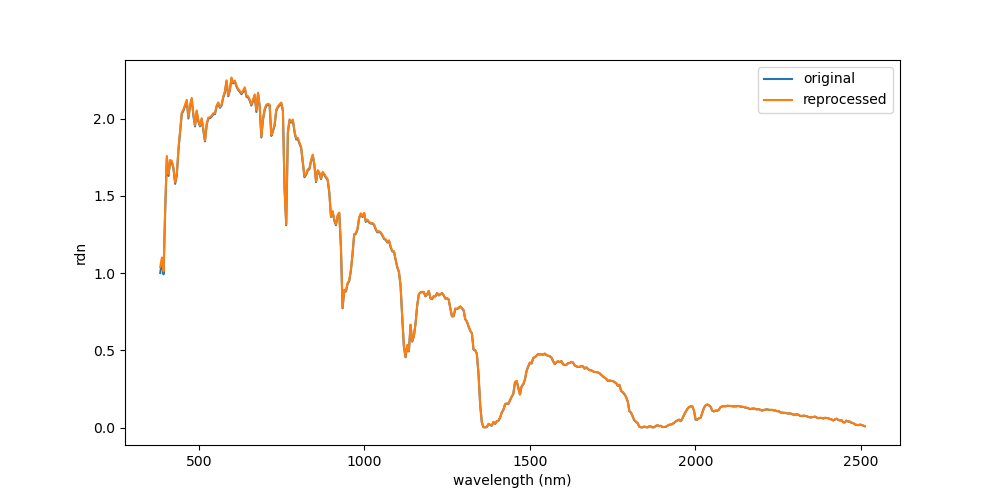

224


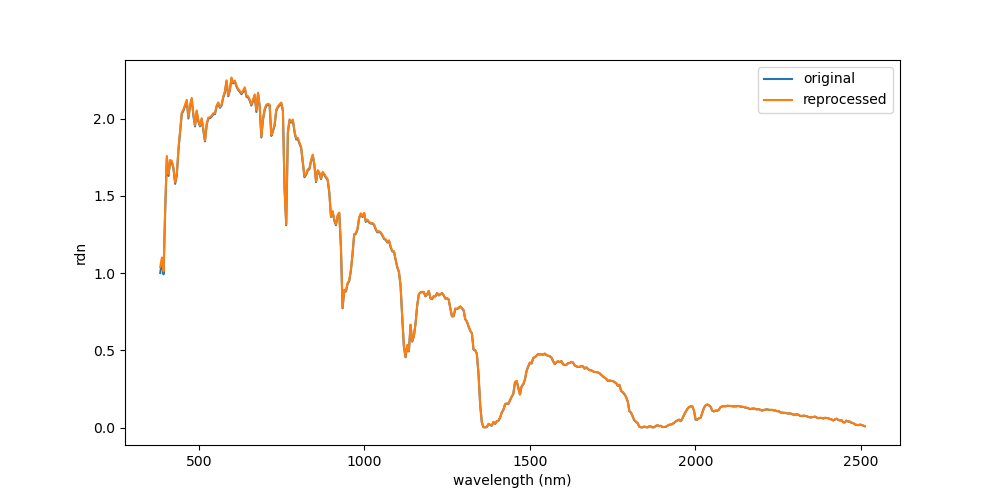

27


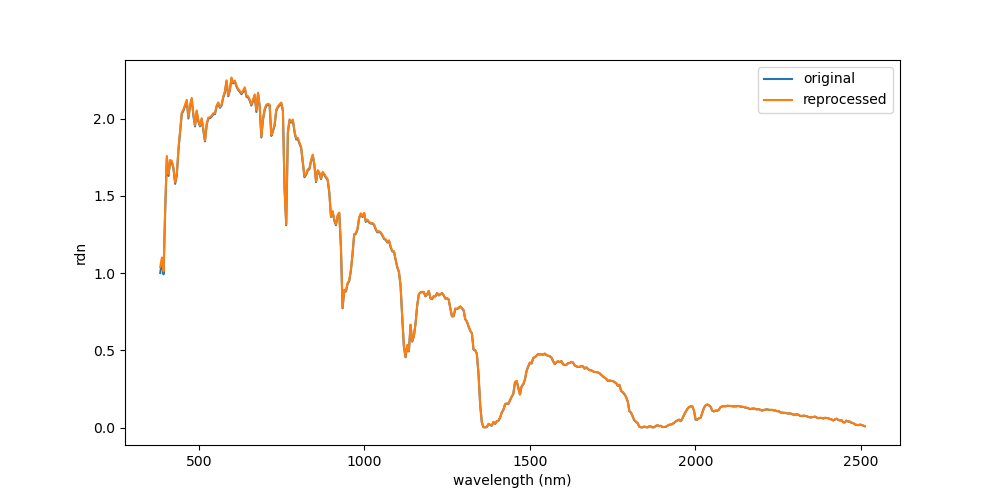

In [7]:
wl = [float(x) for x in read_envi_header(fp_new)['wavelength']]
for i in np.random.randint(0, 500, 5):
    print(i)
    fig = plt.figure(figsize=(10,5))
    plt.plot(wl, rdn_old[dif[0][i], dif[1][i], :], label='original')
    plt.plot(wl, rdn_new[dif[0][i], dif[1][i], :], label='reprocessed')
    plt.legend()
    # plt.xlim(380,500)
    plt.xlabel('wavelength (nm)')
    plt.ylabel('rdn')
    plt.show()

In [7]:
# loc
fp_new = glob(os.path.join(new, '*', f'{flight}*igm*.hdr'))[0]
fp_old = glob(os.path.join(old, '*', f'{flight}*igm*.hdr'))[0]

loc_new = envi.open(fp_new).open_memmap(interleave='bip')
loc_old = envi.open(fp_old).open_memmap(interleave='bip')

print(loc_new.shape, loc_old.shape)

np.array_equal(loc_new, loc_old)

(47530, 598, 3) (47530, 598, 3)


False

In [42]:
dif = np.where(loc_new != loc_old)

In [43]:
set(dif[2])

{0, 1, 2}

(array([6.79767e+05, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.43000e+02, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.87220e+04]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

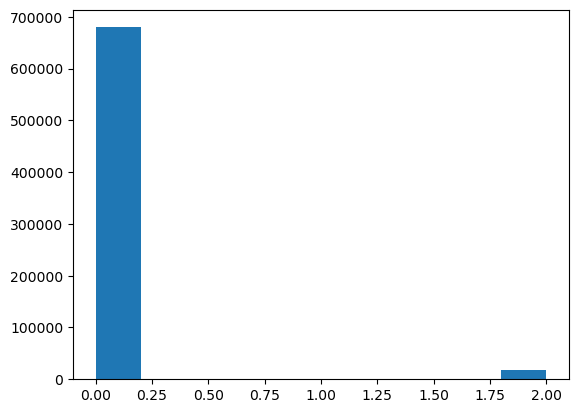

In [39]:
plt.hist(dif[2])

In [22]:
type(shp0)

NoneType

In [11]:
print(dif)
len(dif[0]), len(dif[1]), len(dif[2])

(array([    5,     6,     6, ..., 47517, 47519, 47523]), array([ 12,   0,   1, ..., 508,  77, 589]), array([2, 0, 0, ..., 2, 2, 2]))


(698632, 698632, 698632)

In [44]:
698632/(47530*598)

0.024579864011252884

In [50]:
# obs
fp_new = glob(os.path.join(new, '*', f'{flight}*obs*.hdr'))[0]
fp_old = glob(os.path.join(old, '*', f'{flight}*obs*.hdr'))[0]

obs_new = envi.open(fp_new).open_memmap(interleave='bip')
obs_old = envi.open(fp_old).open_memmap(interleave='bip')

print(obs_new.shape, obs_old.shape)

np.array_equal(obs_new, obs_old)

(24573, 1560, 11) (47530, 598, 10)


False

In [43]:
print(fp_new)
print(fp_old)

/store/carroll/col/2018/raw/rmbl/2018061914/NIS01_20180619_153052_rdn_obs_ort.hdr
/store/brodrick/col/raw_data/all_obs/NIS01_20180619_153052_rdn_obs.hdr
